# Phase 1: Model Building (Task 1)
## a. Base Model 1: Hybrid CNN-LSTM Architecture
**Objective:** Construct a deep neural network combining Convolutional layers (for spatial feature extraction and noise reduction) with LSTM layers (for temporal sequence modeling). The network outputs a single probability indicating whether an engine is currently within the 30-cycle failure risk window.

In [15]:
#importing the need libraries

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization,Flatten, Add,Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#Load the 3D preprocced tensors
x_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')

print(f'Loaded x_train: {x_train.shape}')

Loaded x_train: (15731, 50, 14)


In [26]:
#1 Define the model Structure
def build_hybrid_cnn_lstm (sequence_length, num_features):
    model = Sequential([
        # CNN Block
        Input(shape =(sequence_length, num_features)),
        Conv1D(filters=64, kernel_size= 3, activation='relu',padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # LSTM Block
        LSTM(units = 100, return_sequences= True, activation='tanh'),
        Dropout(0.3),
        LSTM(units=50, return_sequences=False, activation='tanh'),
        Dropout(0.3),

        # classification Head
        Dense(units=32, activation='relu'),
        Dense(units =1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer = optimizer,loss = 'binary_crossentropy', metrics =['accuracy'])
    return model

#instantiate and summarise
model_a = build_hybrid_cnn_lstm(sequence_length=x_train.shape[1], num_features= x_train.shape[2])
model_a.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 25, 100)        │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 25, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,873 (394.04 KB)

 Trainable params: 100,745 (393.54 KB)

 Non-trainable params: 128 (512.00 B)

## basic Model Training & Validation (CNN-LSTM)
**Objective:** Train the Hybrid CNN-LSTM model using an 80/20 train-validation split. Implement an `EarlyStopping` callback to monitor validation loss, preventing the model from overfitting the training data by halting the process when generalization stops improving.

In [9]:
# 1 Configure Early Stopping
# This prevents the model from memorizing the data (overfitting)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,               # If validation loss doesn't improve for 5 epochs, stop.
    restore_best_weights=True # Keep the best performing weights, not the final epoch's weights
)

In [ ]:


# 2. Execute the Training Loop
print(" Starting Model Training on RTX 4050...")
history_a = model_a.fit(
    x_train, y_train,
    epochs=50,                # Max epochs (EarlyStopping will likely stop it sooner)
    batch_size=64,            # Number of sequences processed before updating weights
    validation_split=0.2,     # Automatically holds out the last 20% of data for validation
    callbacks=[early_stop],
    verbose=1
)
print(" Training Complete!")



 Starting Model Training on RTX 4050...
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9452 - loss: 0.1428 - val_accuracy: 0.8278 - val_loss: 0.6306
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9662 - loss: 0.0800 - val_accuracy: 0.9031 - val_loss: 0.1765
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9708 - loss: 0.0713 - val_accuracy: 0.9673 - val_loss: 0.0769
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9786 - loss: 0.0514 - val_accuracy: 0.9501 - val_loss: 0.1697
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9775 - loss: 0.0549 - val_accuracy: 0.9425 - val_loss: 0.1434
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9817 - loss: 0.0426 - val_accuracy: 0.9581 - val_loss: 0.1108
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9841 - loss: 0.0394 - val_accuracy: 0.9406 - val_loss: 0.1066
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - a

# Ploting the results

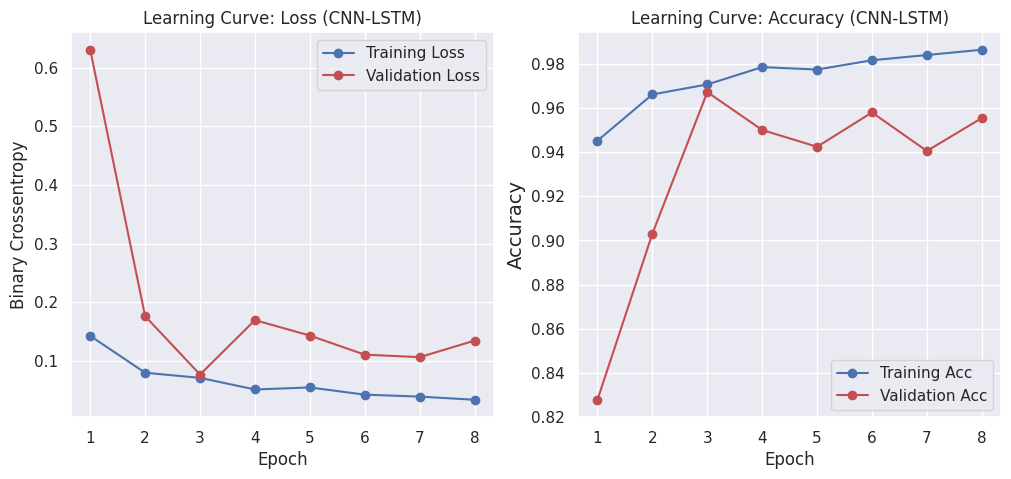

In [38]:


def plot_learning_curves(history_a):
    loss = history_a.history['loss']
    val_loss = history_a.history['val_loss']
    acc = history_a.history['accuracy']
    val_acc = history_a.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    # Plot 2: Loss (The Signal)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Learning Curve: Loss (CNN-LSTM)')
    plt.ylabel('Binary Crossentropy')
    plt.xlabel('Epoch',fontsize =12)
    plt.legend()
    plt.grid(True)

    # Plot 1: Accuracy (The Goal: >80%)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Learning Curve: Accuracy (CNN-LSTM)')
    plt.ylabel('Accuracy', fontsize = 14)
    plt.xlabel('Epoch',fontsize=12)
    plt.legend()
    plt.grid(True)

    

    plt.show()

# Call the function with your history object
plot_learning_curves(history_a)


## 5c. Base Model 2: Temporal Convolutional Network (TCN)
**Objective:** Construct a TCN using dilated causal convolutions. This architecture processes sequences in parallel, often capturing long-range temporal dependencies more efficiently than recurrent networks like LSTMs.

In [ ]:

def residual_block(x, filters,dilation_rate):
    """
    A building bblock for TCN. It applies a dilated convolution and adds
    the original input back in ( a residual connection) to prevent the vanishing gradient problem.
    """

    #keep a copy of the input for the residual connection
    original_x = x

    #1 Dilated Convolution: 'causal padding ensures it only looks at past data, not the future
    x = Conv1D(filters = filters, kernel_size= 3, dilation_rate = dilation_rate,
               padding = 'causal', activation ='relu')(x)
    x = Dropout(0.2)(x)

    #2 Second Convolution
    x = Conv1D(filters = filters, kernel_size= 3, dilation_rate= dilation_rate, 
               padding = 'causal', activation = 'relu')(x)
    x = Dropout(0.2)(x)


    # 3 Adjust the original input layer if the number of filters changed
    if original_x.shape[-1] != filters:
        original_x = Conv1D(filters = filters, kernel_size= 1, padding = 'same')(original_x)

    #4 Residual Addition: Add the processed data to the orriginal data
    res_x = Add()([original_x, x])
    return Activation('relu')(res_x)



def build_tcn(sequence_length, num_features):
    """Construct the full TCN architecture"""
    inputs = Input(shape = (sequence_length, num_features))

    #increase the dilation rate exponetially (1,2,3,4) to look futher back in time
    x = residual_block(inputs, filters=64, dilation_rate=1)
    x = residual_block(x,filters= 64, dilation_rate= 2)
    x = residual_block(x, filters= 64, dilation_rate= 4)

    #Flatten the sequence then output the probability
    x = Flatten()(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs = inputs, outputs = outputs)

    optimizer = Adam(learning_rate = 0.001)
    model.compile(optimizer= optimizer, loss= 'binary_crossentropy', metrics=(['accuracy']))
    return model


#instatiate and summarise the TCN
model_b = build_tcn(sequence_length= x_train.shape[1], num_features= x_train.shape[2])
model_b.summary()
    


    

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 50, 64)    │      2,752 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 50, 64)    │        960 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 64)    │          0 │ conv1d_5[0][0],   │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 50, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 64)    │          0 │ activation[0][0], │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 50, 64)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 50, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 64)    │          0 │ activation_1[0][… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 50, 64)    │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3200)      │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 167,937 (656.00 KB)

 Trainable params: 167,937 (656.00 KB)

 Non-trainable params: 0 (0.00 B)

# Train the TCN

In [10]:
print("Starting TCN Training")

history_b = model_b.fit(
    x_train, y_train,
    epochs= 50,
    batch_size= 64,
    validation_split= 0.2,
    callbacks=[early_stop],#reuse the previous one
    verbose=1

)

print("Training completed")

Starting TCN Training
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9215 - loss: 0.1929 - val_accuracy: 0.9641 - val_loss: 0.0814
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9646 - loss: 0.0833 - val_accuracy: 0.9628 - val_loss: 0.0832
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9669 - loss: 0.0781 - val_accuracy: 0.9600 - val_loss: 0.0852
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9710 - loss: 0.0689 - val_accuracy: 0.9593 - val_loss: 0.0927
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9706 - loss: 0.0683 - val_accuracy: 0.9647 - val_loss: 0.0774
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9716 - loss: 0.0652 - val_accuracy: 0.9593 - val_loss: 0.0818
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9750 - loss: 0.0608 - val_accuracy: 0.9689 - val_loss: 0.0689
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9728 - l

# Visualize the Output

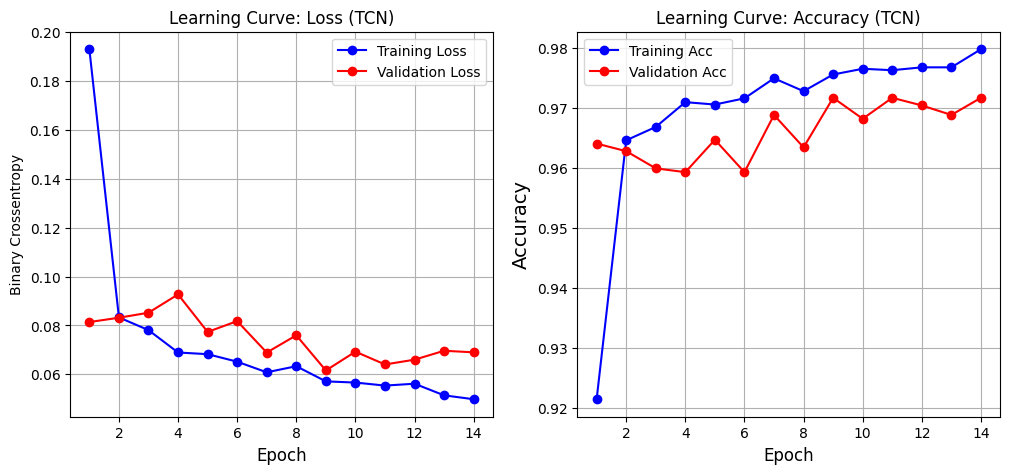

In [14]:


def plot_learning_curves(history_b):
    loss = history_b.history['loss']
    val_loss = history_b.history['val_loss']
    acc = history_b.history['accuracy']
    val_acc = history_b.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    # Plot 2: Loss (The Signal)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Learning Curve: Loss (TCN)')
    plt.ylabel('Binary Crossentropy')
    plt.xlabel('Epoch',fontsize =12)
    plt.legend()
    plt.grid(True)

    # Plot 1: Accuracy (The Goal: >80%)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Learning Curve: Accuracy (TCN)')
    plt.ylabel('Accuracy', fontsize = 14)
    plt.xlabel('Epoch',fontsize=12)
    plt.legend()
    plt.grid(True)

    

    plt.show()

# Call the function with your history object
plot_learning_curves(history_b)
